Accuracy: 0.849701
Precision: 0.300000
Recall: 0.625000
F1-Score: 0.405405
AUC: 0.817161

Starting SHAP analysis...

Top 10 features by mean |SHAP|:
feature  mean_abs_shap
    age       1.563226
    ggt       1.486508
     hr       1.096346
    alt       1.083338
    sua       0.792319
   dbil       0.732569
    rbc       0.687390
     tp       0.531883
   mono       0.520070
    bun       0.455979


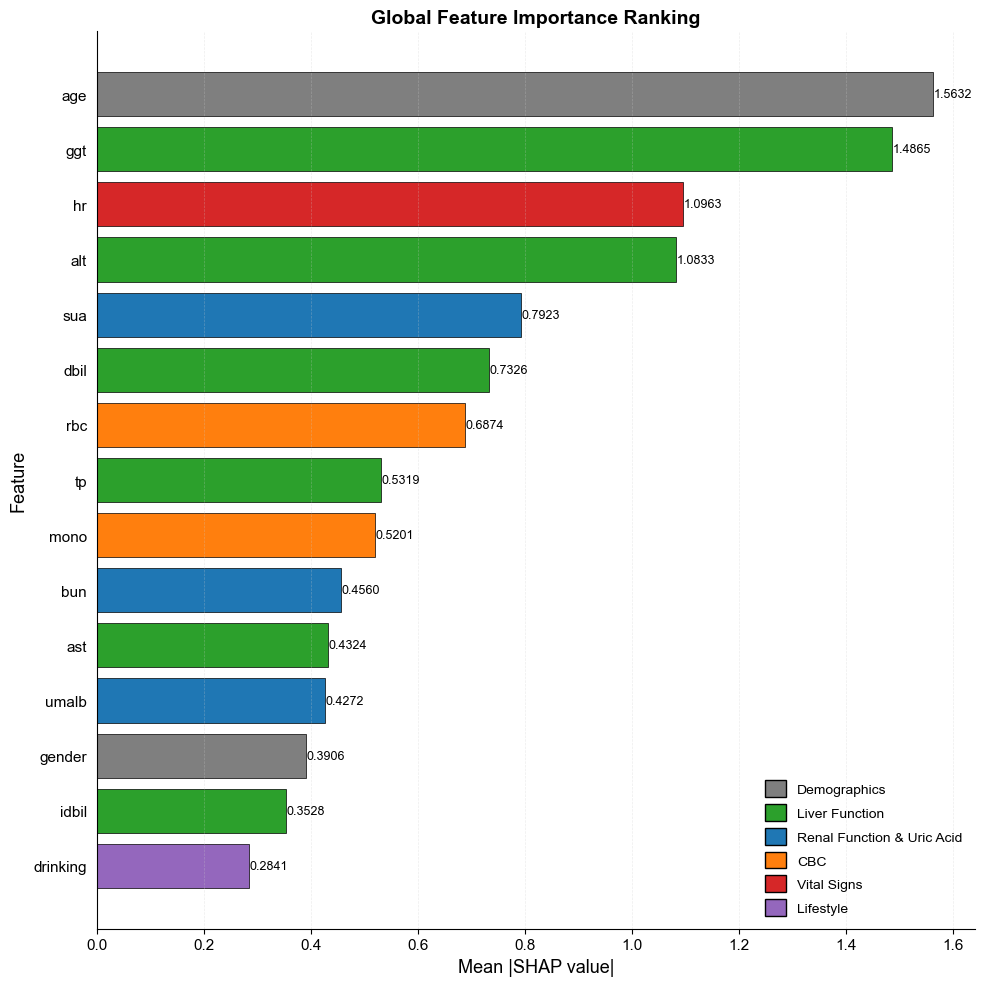

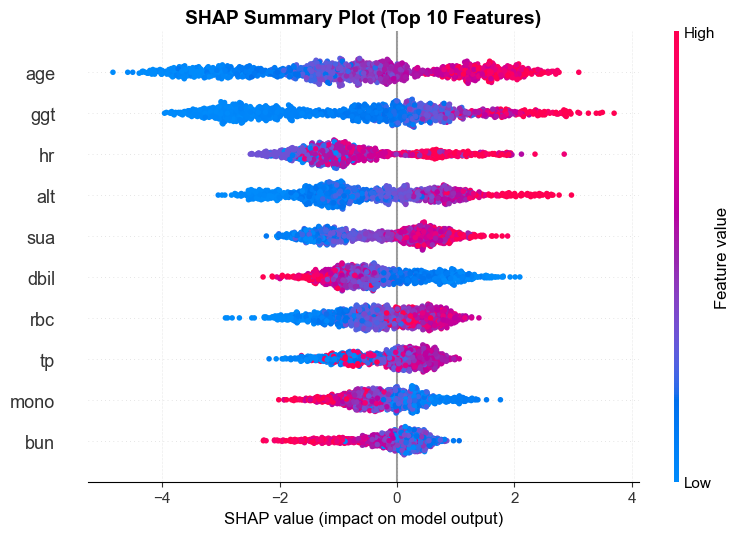

<Figure size 800x600 with 0 Axes>

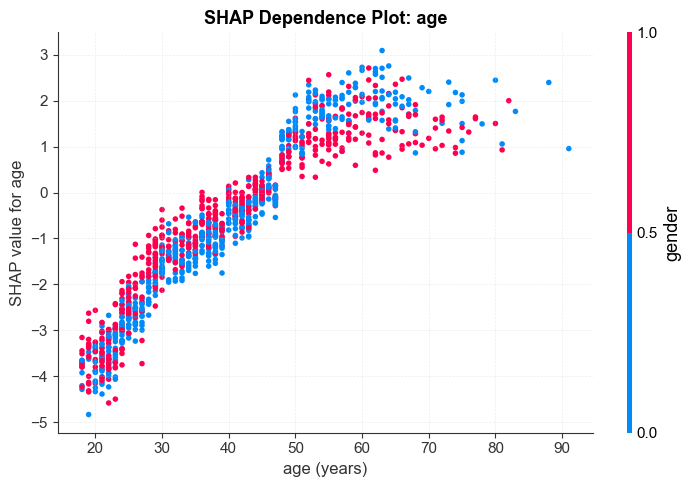

Dependence plot saved: shap_dependence_age.png


<Figure size 800x600 with 0 Axes>

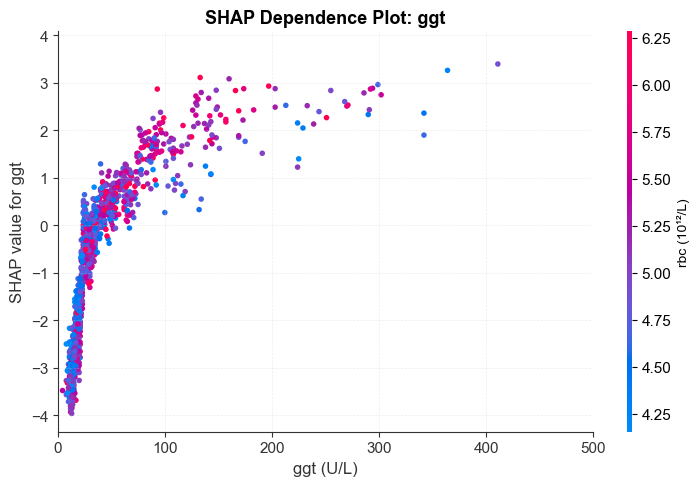

Dependence plot saved: shap_dependence_ggt.png


<Figure size 800x600 with 0 Axes>

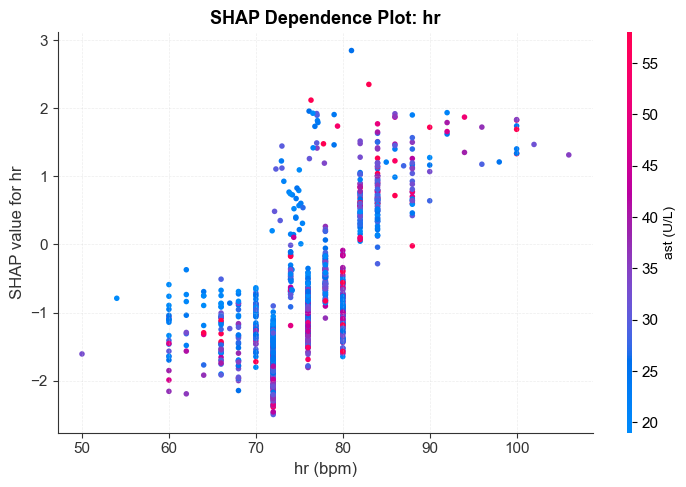

Dependence plot saved: shap_dependence_hr.png


<Figure size 800x600 with 0 Axes>

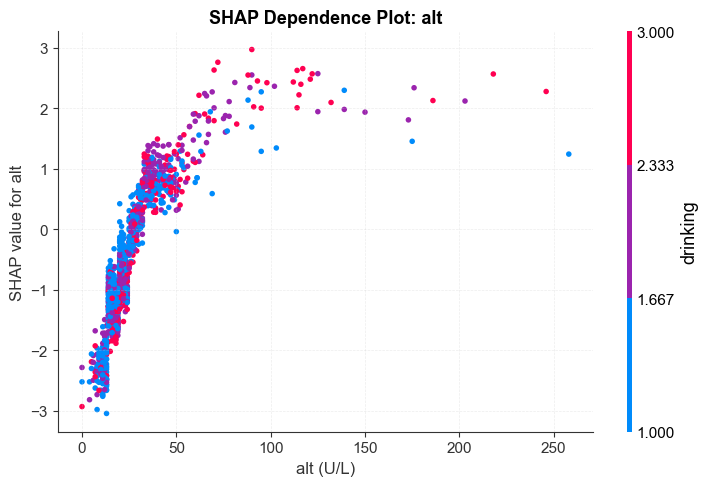

Dependence plot saved: shap_dependence_alt.png
Force plot: TP, index 44, true=1, pred=1


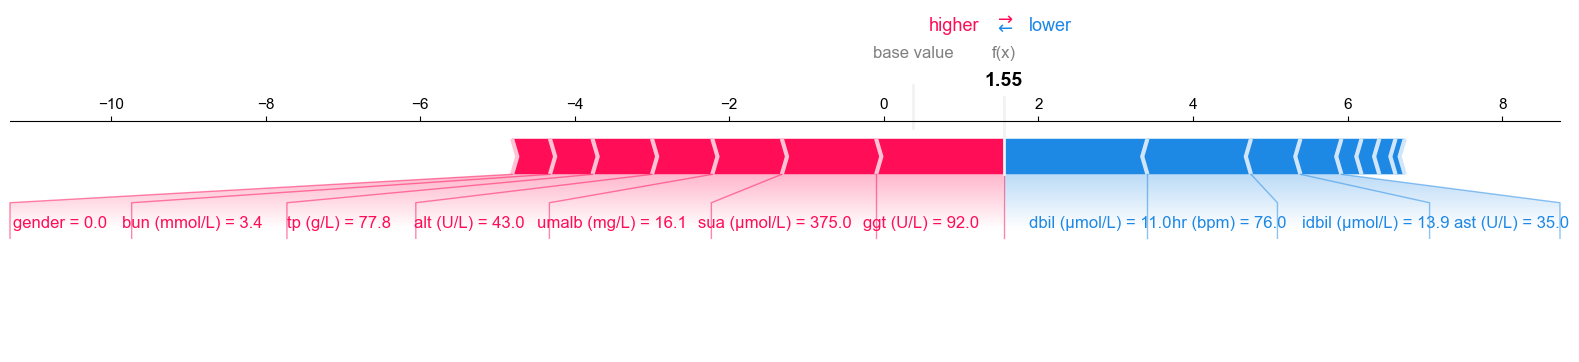

Force plot: TN, index 0, true=0, pred=0


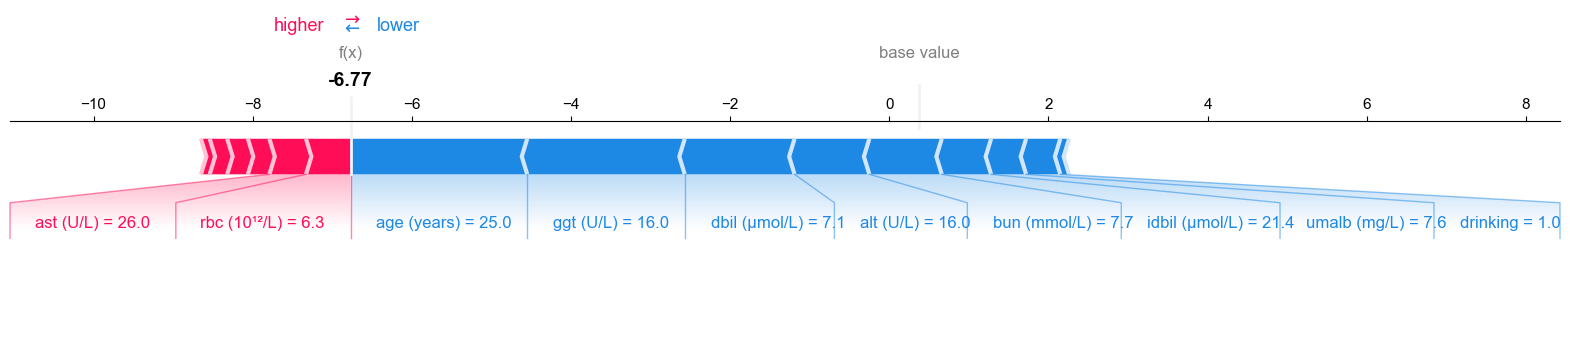


All SHAP plots saved to '../shap_plots' directory.


In [1]:
import pandas as pd
import xgboost as xgb
import os
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.combine import SMOTEENN
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.size'] = 11
mpl.rcParams['font.family'] = 'Arial'

os.environ['LOKY_MAX_CPU_COUNT'] = '6'

SEED = 42

tezheng = ['ggt', 'drinking', 'ast', 'age', 'hr', 'alt', 'mono', 'gender',
           'umalb', 'sua', 'dbil', 'bun', 'tp', 'idbil', 'rbc']

category_color = {
    'Demographics': '#7F7F7F',
    'Liver Function': '#2CA02C',
    'Renal Function & Uric Acid': '#1F77B4',
    'CBC': '#FF7F0E',
    'Vital Signs': '#D62728',
    'Lifestyle': '#9467BD'
}

feature_category = {
    'age': 'Demographics', 'gender': 'Demographics',
    'ggt': 'Liver Function', 'ast': 'Liver Function', 'alt': 'Liver Function',
    'tp': 'Liver Function', 'dbil': 'Liver Function', 'idbil': 'Liver Function',
    'sua': 'Renal Function & Uric Acid', 'bun': 'Renal Function & Uric Acid',
    'umalb': 'Renal Function & Uric Acid',
    'rbc': 'CBC', 'mono': 'CBC',
    'hr': 'Vital Signs',
    'drinking': 'Lifestyle'
}
feature_unit = {
    'ggt': 'U/L', 'drinking': '', 'ast': 'U/L', 'age': 'years', 'hr': 'bpm',
    'alt': 'U/L', 'mono': '%', 'gender': '',
    'umalb': 'mg/L', 'sua': 'μmol/L', 'dbil': 'μmol/L',
    'bun': 'mmol/L', 'tp': 'g/L', 'idbil': 'μmol/L', 'rbc': '10¹²/L'
}
paras = {
    'n_estimators': 514,
    'learning_rate': 0.11483790,
    'max_depth': 14,
    'min_child_weight': 1,
    'subsample': 0.86841410,
    'colsample_bytree': 0.41070400,
    'reg_alpha': 0.12015366,
    'reg_lambda': 0.00028341,
    'gamma': 3.45672074e-06,
    'random_state': 42,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'verbosity': 0
}


df = pd.read_csv('../数据/训练集.csv')
df1 = pd.read_csv('../数据/测试集.csv')

X_train = df.loc[:, tezheng]
y_train = df.loc[:, 'ms_cds']
X_test = df1.loc[:, tezheng]
y_test = df1.loc[:, 'ms_cds']

scaler_params = pd.read_excel('feature_median_iqr.xlsx')
median_dict = dict(zip(scaler_params['feature'], scaler_params['median']))
iqr_dict = dict(zip(scaler_params['feature'], scaler_params['iqr']))

def inverse_robust_scale(X_scaled, feature_names):
    X_orig = X_scaled.copy()
    for col in feature_names:
        if col in median_dict and col in iqr_dict and iqr_dict[col] != 0:
            X_orig[col] = X_scaled[col] * iqr_dict[col] + median_dict[col]
    return X_orig

X_test_original = inverse_robust_scale(X_test, tezheng)

X_train, y_train = SMOTEENN(random_state=SEED, n_jobs=-1).fit_resample(X_train, y_train)

model = xgb.XGBClassifier(**paras, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.6f}")
print(f"Precision: {precision_score(y_test, y_pred):.6f}")
print(f"Recall: {recall_score(y_test, y_pred):.6f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.6f}")
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.6f}")

print("\nStarting SHAP analysis...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({'feature': tezheng, 'mean_abs_shap': mean_abs_shap})
importance_df = importance_df.sort_values('mean_abs_shap', ascending=False)

print("\nTop 10 features by mean |SHAP|:")
print(importance_df.head(10).to_string(index=False))

save_dir = "../shap_plots"
os.makedirs(save_dir, exist_ok=True)

GRID_COLOR = '#cccccc'
GRID_ALPHA = 0.35
GRID_LINESTYLE = '--'
GRID_LINEWIDTH = 0.5

plot_df = importance_df.copy()
plot_df['category'] = plot_df['feature'].map(feature_category)
plot_df['color'] = plot_df['category'].map(category_color)
plot_df = plot_df.iloc[::-1].reset_index(drop=True)

plt.figure(figsize=(10, 10))
ax = plt.gca()
bars = ax.barh(plot_df['feature'], plot_df['mean_abs_shap'],
               color=plot_df['color'], edgecolor='black', linewidth=0.5)

# 数据标签
for bar, val in zip(bars, plot_df['mean_abs_shap']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

# SCI 边框处理
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False, left=False, bottom=True)
ax.xaxis.set_tick_params(width=0.8)

ax.set_xlabel('Mean |SHAP value|', fontsize=13)
ax.set_ylabel('Feature', fontsize=13)
ax.set_title('Global Feature Importance Ranking', fontsize=14, fontweight='bold')

# 仅保留 x 轴方向的网格线
ax.grid(axis='x', color=GRID_COLOR, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)
ax.grid(axis='y', visible=False)  # 不显示横向网格

# 图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat)
                   for cat, color in category_color.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          frameon=False, handlelength=1.5, handleheight=1.5)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "feature_importance_all.png"), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 8))
max_disp = min(10, len(tezheng))
shap.summary_plot(shap_values, X_test, feature_names=tezheng,
                  max_display=max_disp, show=False)
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('SHAP value (impact on model output)', fontsize=12)
ax.set_title('SHAP Summary Plot (Top 10 Features)', fontsize=14, fontweight='bold')

ax.grid(axis='x', color=GRID_COLOR, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "shap_summary_plot.png"), dpi=300, bbox_inches='tight')
plt.show()

top4_features = importance_df.head(4)['feature'].tolist()
for feat in top4_features:
    feat = str(feat)
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(feat, shap_values, X_test_original,
                         feature_names=tezheng, show=False)
    ax = plt.gca()

    unit = feature_unit.get(feat, '')
    xlabel = f'{feat} ({unit})' if unit else feat
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(f'SHAP value for {feat}', fontsize=12)

    if feat == 'ggt':
        plt.xlim(0, 500)

    cbar = None
    for obj in plt.gcf().get_axes():
        if obj != ax and hasattr(obj, 'get_ylabel'):
            cbar = obj
            break
    if cbar is not None:
        cbar_label = cbar.get_ylabel()
        if cbar_label in feature_unit and feature_unit[cbar_label]:
            cbar.set_ylabel(f'{cbar_label} ({feature_unit[cbar_label]})', fontsize=10)
        cbar.spines['top'].set_visible(False)
        cbar.spines['right'].set_visible(False)
        cbar.spines['left'].set_visible(False)
        cbar.spines['bottom'].set_visible(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(True, color=GRID_COLOR, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)

    plt.title(f'SHAP Dependence Plot: {feat}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"shap_dependence_{feat}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Dependence plot saved: shap_dependence_{feat}.png")

feature_names_with_unit = [f"{f} ({feature_unit[f]})" if feature_unit[f] else f for f in tezheng]

tp_pos = np.where((y_test == 1) & (y_pred == 1))[0][0]
tn_pos = np.where((y_test == 0) & (y_pred == 0))[0][0]

decimal_places = 2

for pos, label in zip([tp_pos, tn_pos], ['TP', 'TN']):
    print(f"Force plot: {label}, index {pos}, true={y_test.iloc[pos]}, pred={y_pred[pos]}")
    shap_sample = np.round(shap_values[pos, :], decimal_places)
    X_sample_orig = X_test_original.iloc[pos, :].round(decimal_places)
    force_fig = shap.force_plot(
        base_value=round(explainer.expected_value, decimal_places),
        shap_values=shap_sample,
        features=X_sample_orig,
        feature_names=feature_names_with_unit,
        matplotlib=True,
        show=False
    )
    force_fig.savefig(os.path.join(save_dir, f"force_plot_{label}.png"),
                      dpi=300, bbox_inches='tight')
    plt.show()

print(f"\nAll SHAP plots saved to '{save_dir}' directory.")